<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%203/DS_Practice_Probability_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Data Science
## Week 4 — Probability Intuition via Simulation (Applied)
**Eötvös Loránd University (ELTE) · Faculty of Informatics**

---
**Instructor:** Arafat Md Easin  
**Goal:** By the end of this session you will be able to:
- Build genuine probability intuition by *running experiments*, not just applying formulas
- Verify the Law of Large Numbers and Central Limit Theorem through code
- Simulate and resolve famous probability paradoxes (Monty Hall, Birthday Problem, Gambler's Ruin)
- Estimate probabilities for problems that are hard to solve analytically
- Use bootstrap resampling to quantify uncertainty in real data
- Connect every simulation result back to its closed-form analytical solution

> **Tip:** Run each cell with `Shift + Enter` and read the comments carefully before moving on.  
> **Key principle:** If your simulation disagrees with the formula — check the simulation. If it still disagrees — check the formula.

---
## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Reproducible randomness ───────────────────────────────────────────
# We set a seed so everyone gets the same results.
# In real Monte Carlo work, you'd run without a seed and average over many seeds.
RNG = np.random.default_rng(seed=42)

# ── Plot style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]    = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Setup complete.")

Setup complete.


---
## Part 1 — The Law of Large Numbers (LLN)

The LLN is the mathematical foundation of simulation itself.

> **Theorem (Weak LLN):** For $n$ independent, identically distributed trials with true probability $p$, the empirical frequency $\hat{p}_n$ converges in probability to $p$:
>
> $$\hat{p}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{\;p\;} p \quad \text{as } n \to \infty$$

We will **see** this happen rather than just state it.

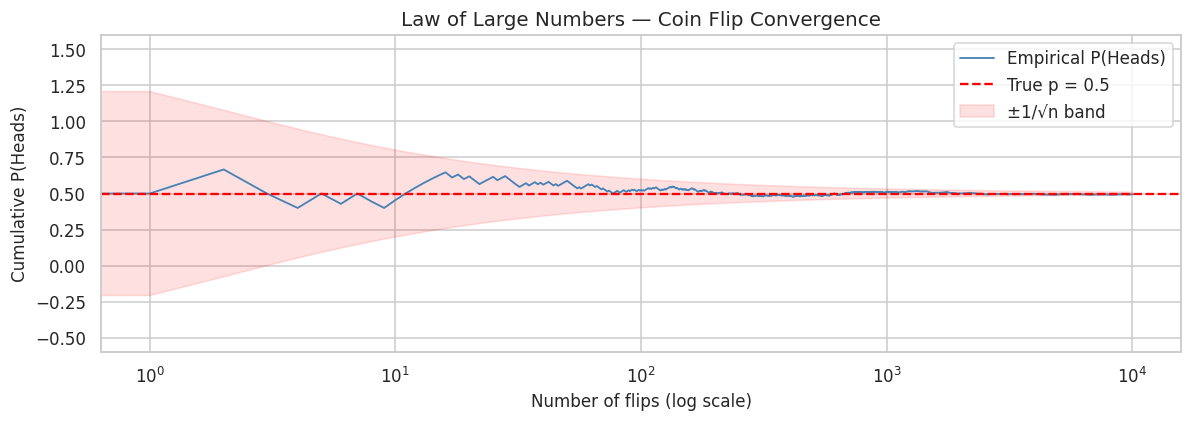

After 10,000 flips:  p̂ = 0.4939   (true p = 0.5000)
Error: 0.0061


In [2]:
# ── 1.1  Coin flip convergence ─────────────────────────────────────────
# Flip a fair coin N times. Watch p̂ converge to 0.5 as N grows.

N     = 10_000
flips = RNG.integers(0, 2, size=N)       # 0 = tails, 1 = heads

# Cumulative mean after each flip
cumulative_mean = np.cumsum(flips) / np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cumulative_mean, color="steelblue", linewidth=1.2, label="Empirical P(Heads)")
ax.axhline(0.5, color="red", linestyle="--", linewidth=1.5, label="True p = 0.5")
ax.fill_between(range(N),
                0.5 - 1/np.sqrt(np.arange(1, N+1)),
                0.5 + 1/np.sqrt(np.arange(1, N+1)),
                alpha=0.12, color="red", label="±1/√n band")
ax.set_xscale("log")
ax.set_xlabel("Number of flips (log scale)")
ax.set_ylabel("Cumulative P(Heads)")
ax.set_title("Law of Large Numbers — Coin Flip Convergence")
ax.legend()
plt.tight_layout()
plt.show()

print(f"After {N:,} flips:  p̂ = {cumulative_mean[-1]:.4f}   (true p = 0.5000)")
print(f"Error: {abs(cumulative_mean[-1] - 0.5):.4f}")

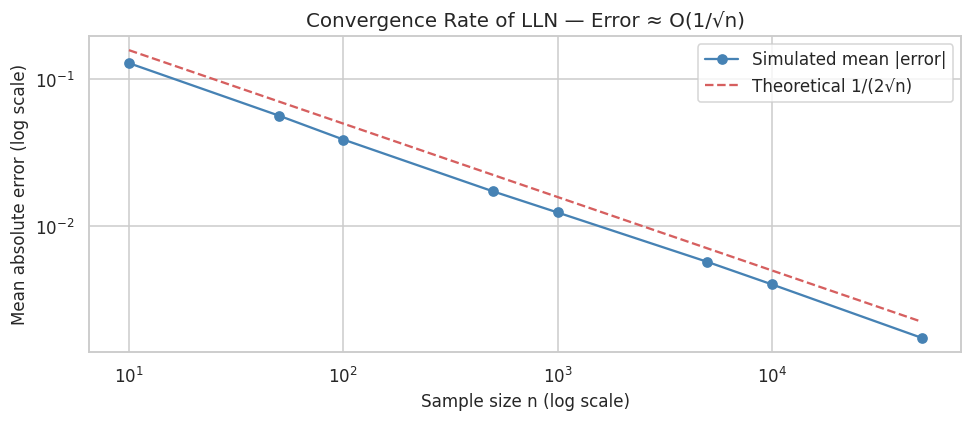

Observation: doubling n halves the error — but only roughly.
To gain one decimal place of accuracy, you need 100× more samples.


In [3]:
# ── 1.2  Rate of convergence for different sample sizes ───────────────
# How fast does the error shrink? By the LLN: error ≈ O(1/√n)

sample_sizes = [10, 50, 100, 500, 1_000, 5_000, 10_000, 50_000]
n_repeats    = 500     # repeat each experiment 500 times
true_p       = 0.5

mean_errors = []
for n in sample_sizes:
    simulations = RNG.integers(0, 2, size=(n_repeats, n)).mean(axis=1)
    mean_errors.append(np.abs(simulations - true_p).mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample_sizes, mean_errors, "o-", color="steelblue", label="Simulated mean |error|")
theoretical = [1 / (2 * np.sqrt(n)) for n in sample_sizes]
ax.plot(sample_sizes, theoretical, "r--", label="Theoretical 1/(2√n)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Sample size n (log scale)")
ax.set_ylabel("Mean absolute error (log scale)")
ax.set_title("Convergence Rate of LLN — Error ≈ O(1/√n)")
ax.legend()
plt.tight_layout()
plt.show()

print("Observation: doubling n halves the error — but only roughly.")
print("To gain one decimal place of accuracy, you need 100× more samples.")

### Exercise 1
A six-sided die is rolled. Simulate the probability of rolling a **5 or 6** for increasing numbers of rolls: `[10, 100, 1000, 10000, 100000]`.

1. Plot the empirical probability as a function of the number of rolls (use a log x-axis)
2. Add a horizontal dashed line at the true probability
3. Print the error at each sample size

```python
# Hint — roll a die:
# RNG.integers(1, 7, size=N)   →  values in {1, 2, 3, 4, 5, 6}
# true probability of 5 or 6 = 2/6 = 1/3
```

In [ ]:
# Your answer here


---
## Part 2 — The Central Limit Theorem (CLT)

The CLT explains why the normal distribution appears everywhere in nature and statistics.

> **Theorem (CLT):** Let $X_1, X_2, \ldots, X_n$ be i.i.d. with mean $\mu$ and variance $\sigma^2 < \infty$. Then:
>
> $$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{\;d\;} \mathcal{N}\!\left(\mu,\, \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty$$
>
> This holds **regardless of the shape of the original distribution**.

We will demonstrate this for three very different parent distributions.

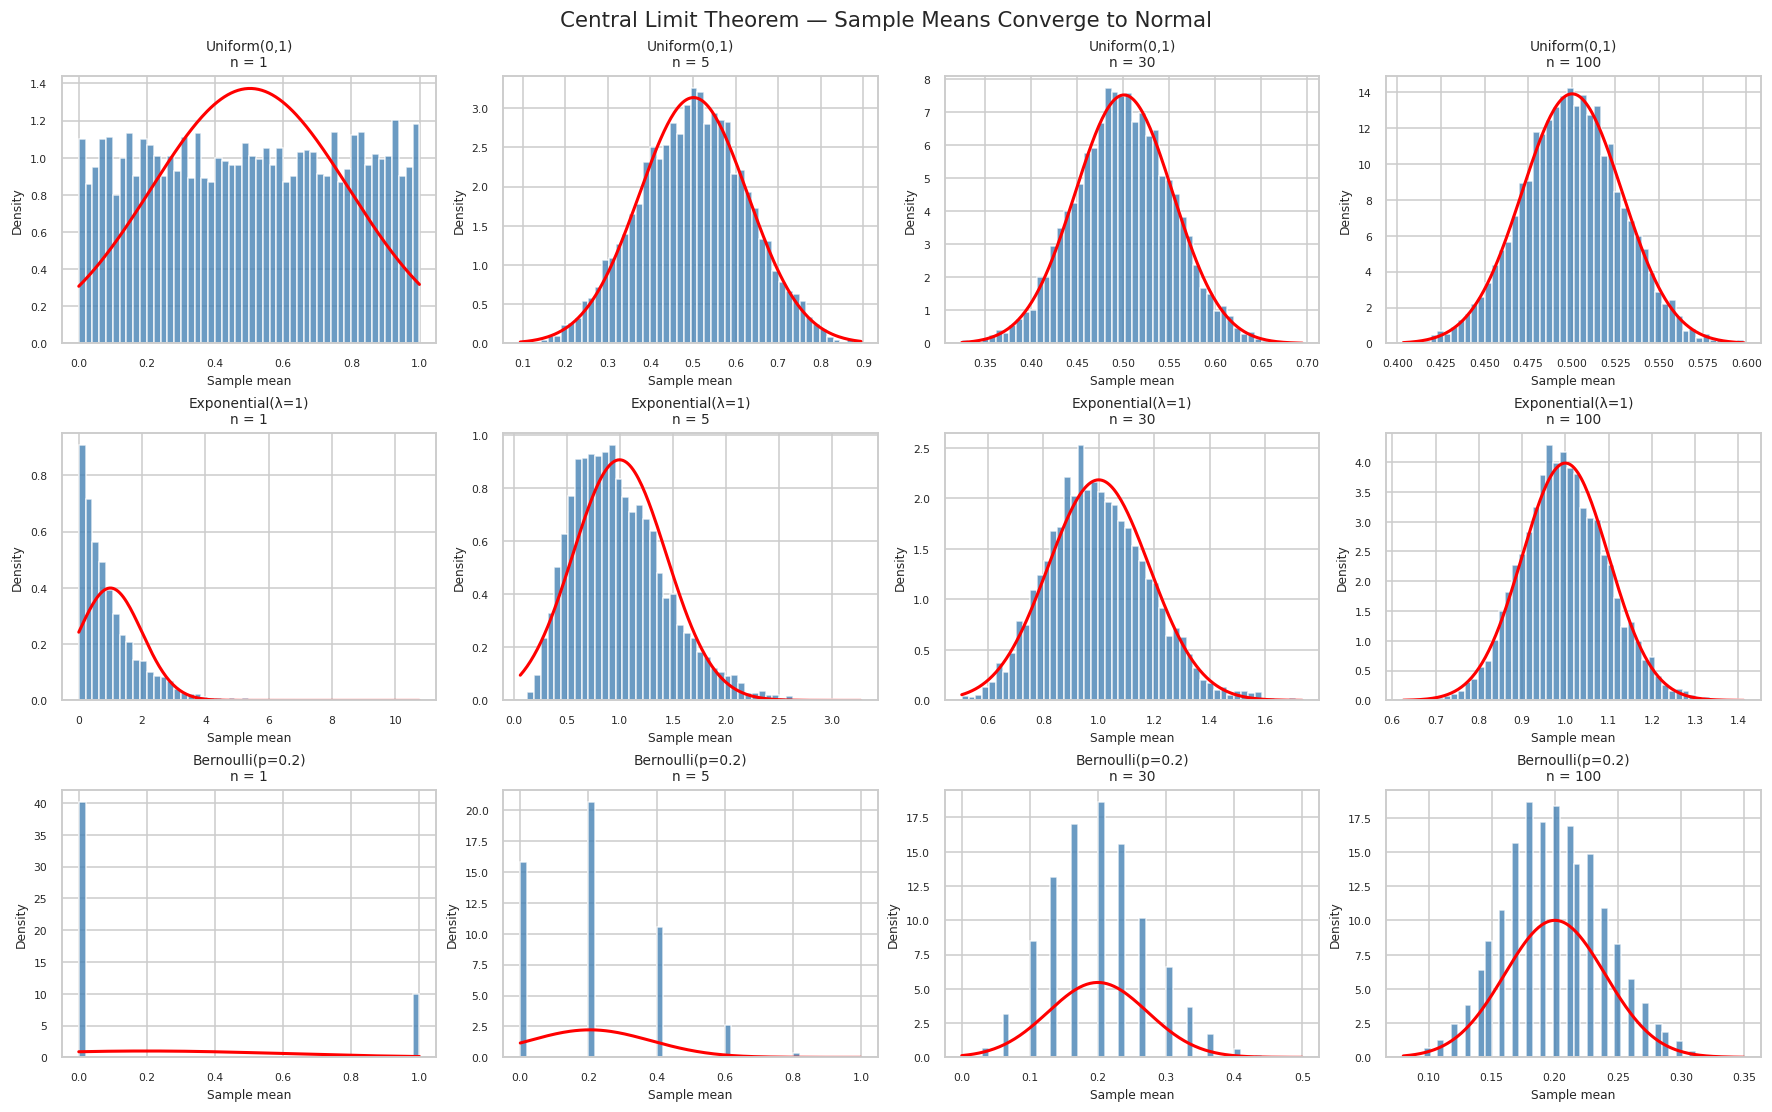

Observation: by n=30, all three distributions produce near-normal sample means.


In [4]:
# ── 2.1  CLT in action — three parent distributions ───────────────────

n_experiments = 5_000   # how many times we draw a sample and compute its mean
sample_sizes  = [1, 5, 30, 100]

# Define three very different distributions
distributions = {
    "Uniform(0,1)": lambda n: RNG.uniform(0, 1, size=n),
    "Exponential(λ=1)": lambda n: RNG.exponential(1, size=n),
    "Bernoulli(p=0.2)": lambda n: RNG.binomial(1, 0.2, size=n),
}

fig, axes = plt.subplots(
    len(distributions), len(sample_sizes),
    figsize=(16, 10),
    constrained_layout=True
)
fig.suptitle("Central Limit Theorem — Sample Means Converge to Normal", fontsize=14)

for row_i, (dist_name, sampler) in enumerate(distributions.items()):
    for col_j, n in enumerate(sample_sizes):
        # Draw n_experiments sample means, each from n observations
        sample_means = [sampler(n).mean() for _ in range(n_experiments)]
        sample_means = np.array(sample_means)

        ax = axes[row_i][col_j]
        ax.hist(sample_means, bins=50, density=True,
                color="steelblue", edgecolor="white", alpha=0.8)

        # Overlay the theoretical normal
        mu_hat = sample_means.mean()
        sd_hat = sample_means.std()
        x_grid = np.linspace(sample_means.min(), sample_means.max(), 200)
        ax.plot(x_grid, stats.norm.pdf(x_grid, mu_hat, sd_hat),
                color="red", linewidth=2)

        ax.set_title(f"{dist_name}\nn = {n}", fontsize=9)
        ax.set_xlabel("Sample mean", fontsize=8)
        ax.set_ylabel("Density", fontsize=8)
        ax.tick_params(labelsize=7)

plt.show()
print("Observation: by n=30, all three distributions produce near-normal sample means.")

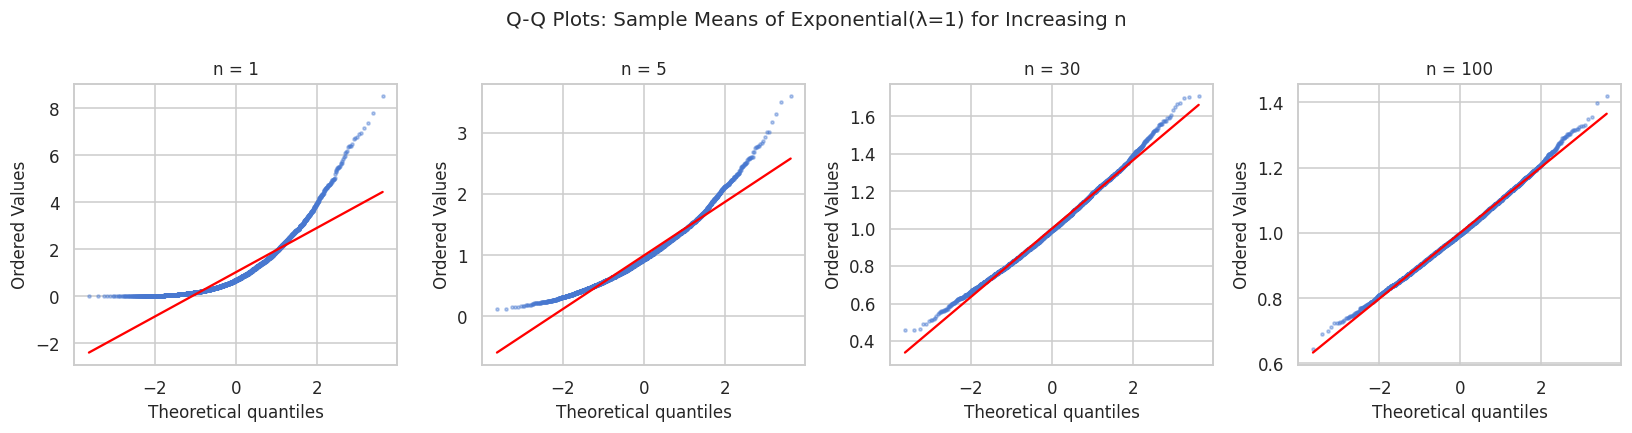

Notice how the S-curve in n=1 straightens into a line by n=30-100.


In [5]:
# ── 2.2  Quantifying normality — Q-Q plots ────────────────────────────
# A Q-Q plot compares quantiles of your data to a theoretical normal.
# Points on the diagonal line → data is normal.

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle("Q-Q Plots: Sample Means of Exponential(λ=1) for Increasing n", fontsize=13)

for ax, n in zip(axes, sample_sizes):
    sample_means = np.array([RNG.exponential(1, size=n).mean()
                             for _ in range(n_experiments)])
    stats.probplot(sample_means, dist="norm", plot=ax)
    ax.set_title(f"n = {n}", fontsize=11)
    ax.get_lines()[0].set(markersize=2, alpha=0.4)
    ax.get_lines()[1].set(color="red", linewidth=1.5)

plt.tight_layout()
plt.show()

print("Notice how the S-curve in n=1 straightens into a line by n=30-100.")

### Exercise 2
The **Poisson distribution** with λ=3 is discrete and right-skewed.

1. Draw `n_experiments = 3000` sample means for `n ∈ {1, 10, 50}`  
2. Plot histograms with a fitted normal curve overlay  
3. At what value of n does the distribution look approximately normal to you?

```python
# Hint:
# RNG.poisson(lam=3, size=n)   →  Poisson(λ=3) sample of size n
# True mean = λ = 3,   True variance = λ = 3
```

In [ ]:
# Your answer here


---
## Part 3 — Classic Probability Paradoxes

The following problems are famous because human intuition gets them badly wrong.  
Simulation gives us an undeniable empirical answer, which we then reconcile with theory.

---
### 3.1 — The Monty Hall Problem

**Setup:** There are 3 doors. Behind one is a car; behind the others are goats. You pick a door. The host (who knows where the car is) opens a different door revealing a goat. You may **stick** with your original choice or **switch**.

**Question:** Should you switch?

| Strategy | Your intuition | True probability |
|---|---|---|
| Stick | 50%? | **1/3** |
| Switch | 50%? | **2/3** |

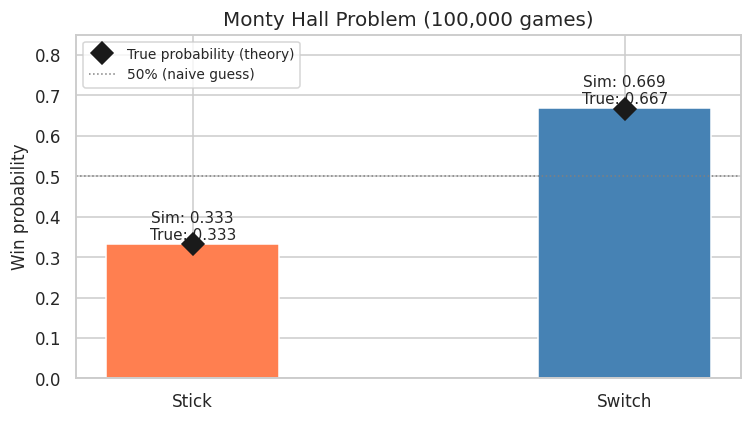


→ Stick:  simulated = 0.333,  theoretical = 1/3 = 0.333
→ Switch: simulated = 0.669,  theoretical = 2/3 = 0.667

 Switching is ALWAYS the better strategy — it wins twice as often.


In [6]:
# ── 3.1  Monty Hall Simulation ─────────────────────────────────────────

def monty_hall(n_games=100_000, switch=True):
    """
    Simulate n_games of the Monty Hall problem.
    Returns the fraction of games won.
    """
    # Place the car randomly behind door 0, 1, or 2
    car_door    = RNG.integers(0, 3, size=n_games)
    # Player picks a door randomly
    player_door = RNG.integers(0, 3, size=n_games)

    wins = 0
    for i in range(n_games):
        if switch:
            # After host reveals a goat, player switches
            # Switching wins iff the original choice was wrong
            wins += (player_door[i] != car_door[i])
        else:
            # Staying wins iff the original choice was correct
            wins += (player_door[i] == car_door[i])

    return wins / n_games

n = 100_000
p_switch = monty_hall(n, switch=True)
p_stick  = monty_hall(n, switch=False)

fig, ax = plt.subplots(figsize=(7, 4))
strategies = ["Stick", "Switch"]
probs      = [p_stick, p_switch]
theory     = [1/3, 2/3]
colors     = ["coral", "steelblue"]

bars = ax.bar(strategies, probs, color=colors, edgecolor="white", width=0.4)
ax.plot(strategies, theory, "kD", markersize=10, label="True probability (theory)", zorder=5)
ax.axhline(0.5, color="grey", linestyle=":", linewidth=1, label="50% (naive guess)")

for bar, p, t in zip(bars, probs, theory):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"Sim: {p:.3f}\nTrue: {t:.3f}", ha="center", fontsize=10)

ax.set_ylim(0, 0.85)
ax.set_ylabel("Win probability")
ax.set_title(f"Monty Hall Problem ({n:,} games)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n→ Stick:  simulated = {p_stick:.3f},  theoretical = 1/3 = {1/3:.3f}")
print(f"→ Switch: simulated = {p_switch:.3f},  theoretical = 2/3 = {2/3:.3f}")
print("\n Switching is ALWAYS the better strategy — it wins twice as often.")

**Why does switching work?**

When you first pick, probability is 1/3 your door has the car, and 2/3 it's behind one of the other two. After the host removes a goat door, that full 2/3 probability collapses onto the single remaining door. Switching transfers you to that 2/3-probability door.

---
### 3.2 — The Birthday Problem

**Question:** In a group of $n$ people, what is the probability that at least two share a birthday?

Most people think you need around 183 people for a 50% chance. The correct answer is **23**.

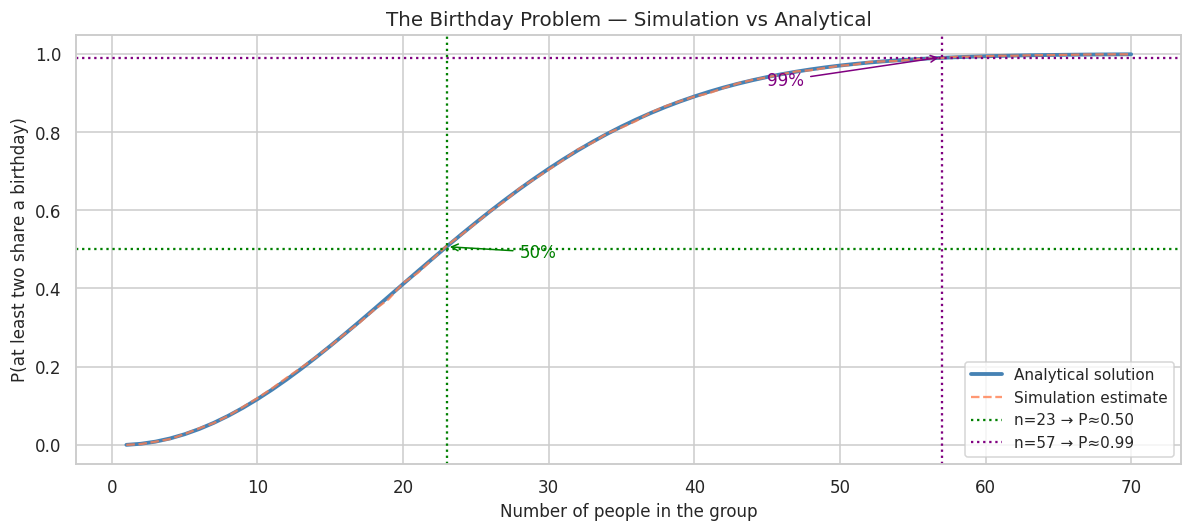

P(shared birthday | n=23):  exact = 0.5073
P(shared birthday | n=57):  exact = 0.9901
P(shared birthday | n=70):  exact = 0.9992


In [7]:
# ── 3.2  Birthday Problem Simulation ──────────────────────────────────

def birthday_probability_simulation(n_people, n_trials=20_000):
    """Estimate P(at least one shared birthday) for a group of n people."""
    birthdays = RNG.integers(1, 366, size=(n_trials, n_people))
    # For each trial, check if any birthday appears more than once
    shared = np.array([
        len(set(birthdays[i])) < n_people
        for i in range(n_trials)
    ])
    return shared.mean()

def birthday_probability_exact(n):
    """Analytical formula: P(at least one match) = 1 - P(all unique)."""
    p_all_unique = 1.0
    for i in range(n):
        p_all_unique *= (365 - i) / 365
    return 1 - p_all_unique

group_sizes = range(1, 71)
exact_probs = [birthday_probability_exact(n) for n in group_sizes]
sim_probs   = [birthday_probability_simulation(n) for n in range(1, 71)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(group_sizes, exact_probs, color="steelblue",  linewidth=2.5, label="Analytical solution")
ax.plot(group_sizes, sim_probs,   color="coral", linestyle="--", linewidth=1.5,
        alpha=0.8, label="Simulation estimate")
ax.axhline(0.5,  color="green",  linestyle=":", linewidth=1.5)
ax.axhline(0.99, color="purple", linestyle=":", linewidth=1.5)
ax.axvline(23, color="green",  linestyle=":", linewidth=1.5,
           label="n=23 → P≈0.50")
ax.axvline(57, color="purple", linestyle=":", linewidth=1.5,
           label="n=57 → P≈0.99")

ax.annotate("50%", xy=(23, 0.507), xytext=(28, 0.48),
            fontsize=11, color="green",
            arrowprops=dict(arrowstyle="->", color="green"))
ax.annotate("99%", xy=(57, 0.992), xytext=(45, 0.92),
            fontsize=11, color="purple",
            arrowprops=dict(arrowstyle="->", color="purple"))

ax.set_xlabel("Number of people in the group")
ax.set_ylabel("P(at least two share a birthday)")
ax.set_title("The Birthday Problem — Simulation vs Analytical")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"P(shared birthday | n=23):  exact = {birthday_probability_exact(23):.4f}")
print(f"P(shared birthday | n=57):  exact = {birthday_probability_exact(57):.4f}")
print(f"P(shared birthday | n=70):  exact = {birthday_probability_exact(70):.4f}")

**Why is 23 so small?**

With $n$ people, there are $\binom{n}{2} = \frac{n(n-1)}{2}$ pairs. At $n=23$, that's $\binom{23}{2} = 253$ pairs — each with a small but non-negligible chance of a match.

---
### 3.3 — The Gambler's Ruin

**Setup:** A gambler starts with \$k. They repeatedly bet \$1 on a fair coin flip. They stop when they reach \$N (win) or \$0 (ruined).

**Analytical result:** $P(\text{ruin}) = 1 - \dfrac{k}{N}$

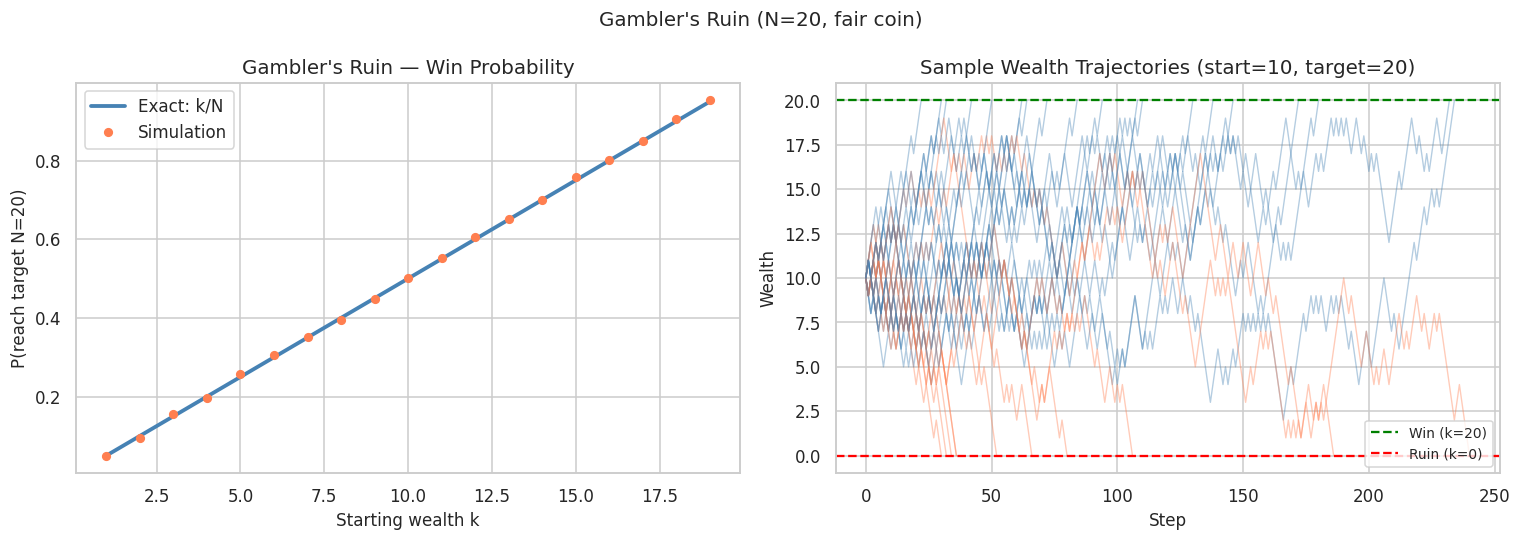

Start = 10, Target = 20
  P(win)  — exact: 0.500   simulation: 0.503
  P(ruin) — exact: 0.500   simulation: 0.500


In [8]:
# ── 3.3  Gambler's Ruin Simulation ────────────────────────────────────

def gambler_ruin_sim(start, target, n_games=10_000):
    """Simulate n_games of Gambler's Ruin. Returns P(reach target)."""
    wins = 0
    for _ in range(n_games):
        wealth = start
        while 0 < wealth < target:
            wealth += RNG.choice([-1, 1])   # fair coin: +1 or -1
        if wealth == target:
            wins += 1
    return wins / n_games

# Show how ruin probability changes with starting wealth
N         = 20        # target wealth
starts    = range(1, N)
sim_probs = [gambler_ruin_sim(k, N) for k in starts]
exact     = [k / N for k in starts]   # analytical formula

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: win probability vs starting wealth
axes[0].plot(starts, exact,     color="steelblue", linewidth=2.5, label="Exact: k/N")
axes[0].plot(starts, sim_probs, "o", color="coral",  markersize=5,  label="Simulation")
axes[0].set_xlabel("Starting wealth k")
axes[0].set_ylabel("P(reach target N=20)")
axes[0].set_title("Gambler's Ruin — Win Probability")
axes[0].legend()

# Right: sample trajectories
axes[1].set_title("Sample Wealth Trajectories (start=10, target=20)")
for _ in range(30):
    wealth = 10
    path   = [wealth]
    while 0 < wealth < 20 and len(path) < 400:
        wealth += RNG.choice([-1, 1])
        path.append(wealth)
    color = "steelblue" if path[-1] == 20 else "coral"
    axes[1].plot(path, color=color, alpha=0.4, linewidth=0.9)

axes[1].axhline(20, color="green", linestyle="--", label="Win (k=20)")
axes[1].axhline(0,  color="red",   linestyle="--", label="Ruin (k=0)")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Wealth")
axes[1].legend(fontsize=9)

plt.suptitle("Gambler's Ruin (N=20, fair coin)", fontsize=13)
plt.tight_layout()
plt.show()

k = 10
print(f"Start = {k}, Target = {N}")
print(f"  P(win)  — exact: {k/N:.3f}   simulation: {gambler_ruin_sim(k, N):.3f}")
print(f"  P(ruin) — exact: {1 - k/N:.3f}   simulation: {1 - gambler_ruin_sim(k, N):.3f}")

### Exercise 3
**Extend the Gambler's Ruin** to an **unfair coin** with $P(\text{win}) = p = 0.45$ (like a casino game).

The analytical win probability for a biased coin is:
$$P(\text{win} \mid k) = \frac{1 - (q/p)^k}{1 - (q/p)^N}, \quad q = 1 - p$$

1. Simulate 5,000 games for `k` in `range(1, 20)` with `N=20`, `p=0.45`
2. Plot simulated vs analytical win probability
3. Compare the plot to the fair-coin case above. What do you notice?

```python
# Hint — biased coin step:
# step = RNG.choice([-1, 1], p=[1-p_win, p_win])
```

In [ ]:
# Your answer here


---
## Part 4 — Monte Carlo Estimation

Monte Carlo methods estimate quantities by random sampling. The canonical example is estimating $\pi$.

**Idea:** A unit circle inscribed in a 2×2 square has area ratio $\pi/4$. If we throw random darts at the square, the fraction that land inside the circle estimates $\pi/4$.

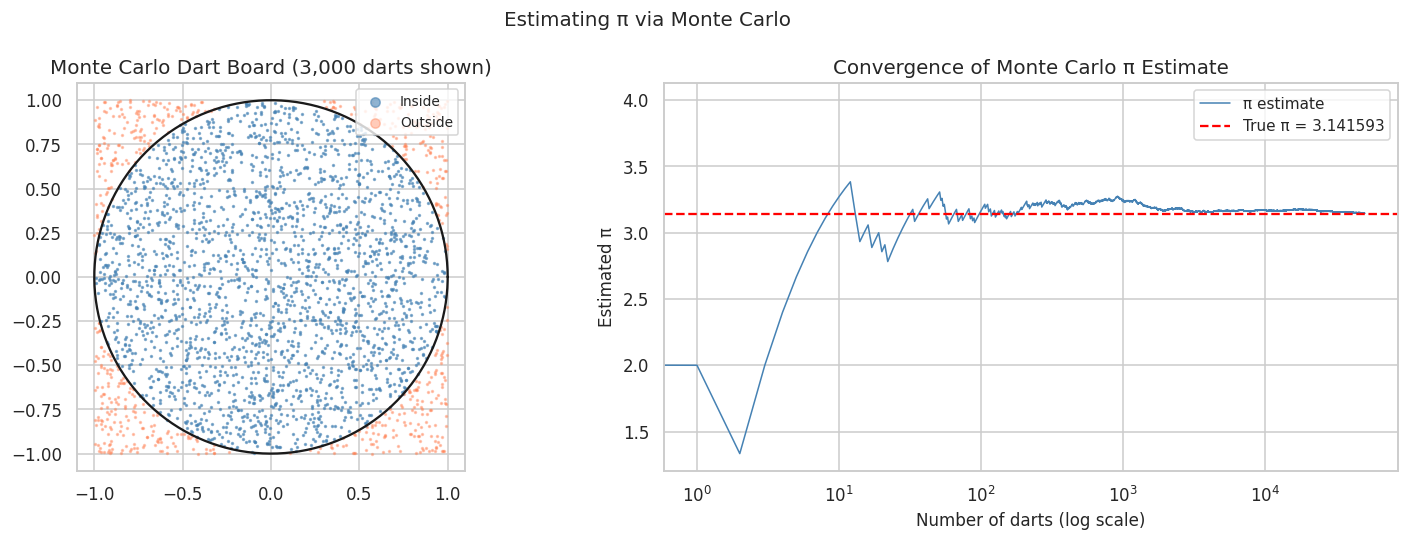

Final estimate:  π ≈ 3.14720
True value:      π  = 3.14159
Absolute error:      0.00561


In [9]:
# ── 4.1  Estimating π by Monte Carlo ─────────────────────────────────

N  = 50_000
x  = RNG.uniform(-1, 1, size=N)
y  = RNG.uniform(-1, 1, size=N)
inside = x**2 + y**2 <= 1

pi_estimates = 4 * np.cumsum(inside) / np.arange(1, N + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter plot of darts
n_show = 3_000
axes[0].scatter(x[:n_show][inside[:n_show]],  y[:n_show][inside[:n_show]],
                s=1.5, color="steelblue", alpha=0.6, label="Inside")
axes[0].scatter(x[:n_show][~inside[:n_show]], y[:n_show][~inside[:n_show]],
                s=1.5, color="coral",     alpha=0.4, label="Outside")
theta = np.linspace(0, 2 * np.pi, 300)
axes[0].plot(np.cos(theta), np.sin(theta), "k-", linewidth=1.5)
axes[0].set_aspect("equal")
axes[0].set_title(f"Monte Carlo Dart Board ({n_show:,} darts shown)")
axes[0].legend(fontsize=9, markerscale=5)

# Right: convergence to π
axes[1].plot(pi_estimates, color="steelblue", linewidth=1, label="π estimate")
axes[1].axhline(np.pi, color="red", linestyle="--", linewidth=1.5,
                label=f"True π = {np.pi:.6f}")
axes[1].set_xscale("log")
axes[1].set_xlabel("Number of darts (log scale)")
axes[1].set_ylabel("Estimated π")
axes[1].set_title("Convergence of Monte Carlo π Estimate")
axes[1].legend(fontsize=10)

plt.suptitle("Estimating π via Monte Carlo", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Final estimate:  π ≈ {pi_estimates[-1]:.5f}")
print(f"True value:      π  = {np.pi:.5f}")
print(f"Absolute error:      {abs(pi_estimates[-1] - np.pi):.5f}")

In [10]:
# ── 4.2  Monte Carlo Integration (general case) ───────────────────────
# Estimate ∫₀¹ √(1 - x²) dx  =  π/4
# Method: sample x ~ Uniform(0,1), evaluate f(x), average.
#
#   ∫_a^b f(x) dx  ≈  (b - a) × (1/N) Σ f(xᵢ)

def monte_carlo_integrate(f, a, b, N=100_000):
    """Estimate ∫_a^b f(x) dx using Monte Carlo."""
    x_samples = RNG.uniform(a, b, size=N)
    return (b - a) * f(x_samples).mean()

# Test on known integrals
tests = [
    ("∫₀¹ x² dx",              lambda x: x**2,                  0, 1,  1/3),
    ("∫₀¹ √(1-x²) dx  = π/4", lambda x: np.sqrt(1 - x**2),    0, 1,  np.pi/4),
    ("∫₀^π sin(x) dx",         lambda x: np.sin(x),            0, np.pi, 2.0),
    ("∫₁^e 1/x dx  = 1",       lambda x: 1/x,                   1, np.e, 1.0),
]

print(f"{'Integral':<30} {'Estimate':>10} {'True':>10} {'Error':>10}")
print("-" * 65)
for name, f, a, b, true_val in tests:
    est = monte_carlo_integrate(f, a, b)
    print(f"{name:<30} {est:>10.5f} {true_val:>10.5f} {abs(est-true_val):>10.5f}")

Integral                         Estimate       True      Error
-----------------------------------------------------------------
∫₀¹ x² dx                         0.33324    0.33333    0.00010
∫₀¹ √(1-x²) dx  = π/4             0.78565    0.78540    0.00026
∫₀^π sin(x) dx                    2.00051    2.00000    0.00051
∫₁^e 1/x dx  = 1                  1.00060    1.00000    0.00060


### Exercise 4
Use Monte Carlo integration to estimate the following integral, which has no closed form:

$$\int_0^1 e^{-x^2} \, dx$$

The true value (from a table) is approximately **0.74682**.

1. Estimate using `N = 1000`, `10000`, `100000`, `1000000`
2. Print the estimate and absolute error at each N
3. How does the error change as N grows? Is it consistent with O(1/√N)?

In [ ]:
# Your answer here


---
## Part 5 — Bootstrap Resampling

The **bootstrap** is a simulation-based method for quantifying uncertainty in any statistic.

**The problem:** We have a sample and compute a statistic (mean, median, correlation…). How confident should we be in this estimate? How wide is the sampling distribution?

**Bootstrap idea:**
1. Draw $B$ re-samples of size $n$ **with replacement** from your data
2. Compute your statistic on each re-sample → $B$ bootstrap estimates
3. The spread of these estimates approximates the **sampling distribution**

$$\text{Bootstrap SE} \approx \text{std}(\{\hat{\theta}^{*1}, \hat{\theta}^{*2}, \ldots, \hat{\theta}^{*B}\})$$

In [11]:
# ── 5.1  Load a real dataset ──────────────────────────────────────────
# We'll use the classic iris dataset — available in seaborn

iris = sns.load_dataset("iris")
sample = iris.loc[iris["species"] == "setosa", "sepal_length"].values

print(f"Sample: setosa sepal_length, n = {len(sample)}")
print(f"Observed mean:   {sample.mean():.4f}")
print(f"Observed median: {np.median(sample):.4f}")
print(f"Observed std:    {sample.std(ddof=1):.4f}")

Sample: setosa sepal_length, n = 50
Observed mean:   5.0060
Observed median: 5.0000
Observed std:    0.3525


In [12]:
# ── 5.2  Bootstrap confidence interval for the mean ───────────────────

def bootstrap(data, statistic, B=10_000, ci=0.95):
    """
    Compute a bootstrap confidence interval for any statistic.

    Parameters
    ----------
    data      : 1-D array of observed values
    statistic : callable, e.g. np.mean or np.median
    B         : number of bootstrap re-samples
    ci        : confidence level (default 0.95)

    Returns
    -------
    (lower, upper, boot_dist)
    """
    n     = len(data)
    boot_stats = np.array([
        statistic(RNG.choice(data, size=n, replace=True))
        for _ in range(B)
    ])
    alpha = (1 - ci) / 2
    lower = np.quantile(boot_stats, alpha)
    upper = np.quantile(boot_stats, 1 - alpha)
    return lower, upper, boot_stats

# Run bootstrap for mean and median
ci_mean_lo, ci_mean_hi, boot_means   = bootstrap(sample, np.mean)
ci_med_lo,  ci_med_hi,  boot_medians = bootstrap(sample, np.median)

print("Bootstrap 95% CIs:")
print(f"  Mean:   [{ci_mean_lo:.4f},  {ci_mean_hi:.4f}]   (observed = {sample.mean():.4f})")
print(f"  Median: [{ci_med_lo:.4f},  {ci_med_hi:.4f}]   (observed = {np.median(sample):.4f})")

Bootstrap 95% CIs:
  Mean:   [4.9120,  5.1020]   (observed = 5.0060)
  Median: [4.9000,  5.1000]   (observed = 5.0000)


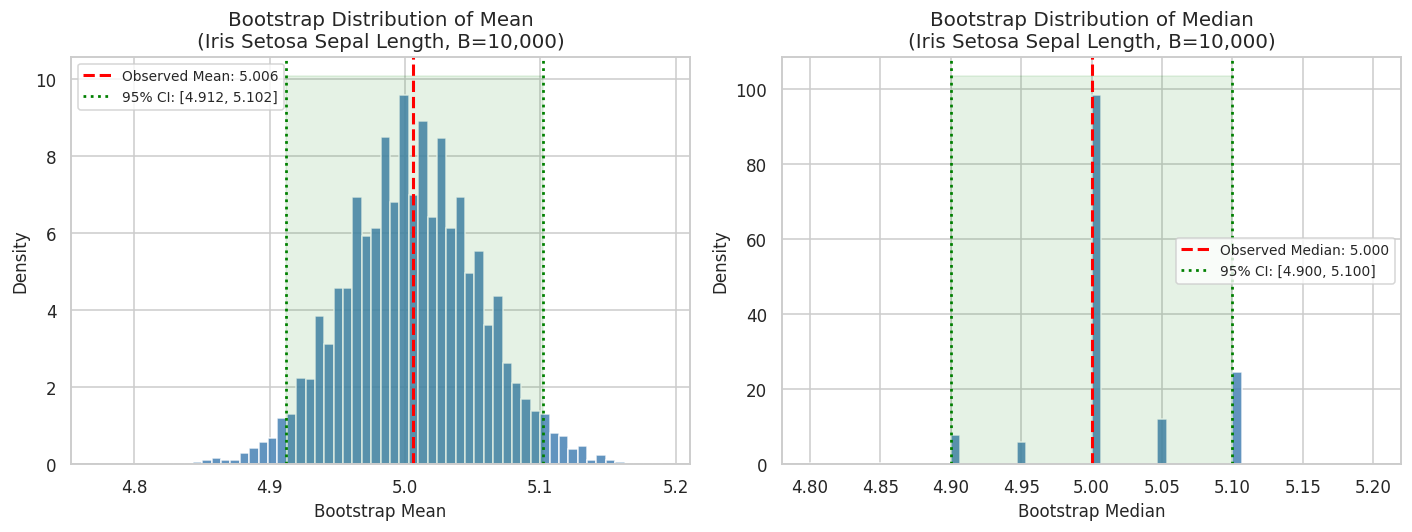

In [13]:
# ── 5.3  Visualise bootstrap distributions ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, boot_dist, stat_name, obs_val, lo, hi in [
    (axes[0], boot_means,   "Mean",   sample.mean(),    ci_mean_lo, ci_mean_hi),
    (axes[1], boot_medians, "Median", np.median(sample), ci_med_lo,  ci_med_hi),
]:
    ax.hist(boot_dist, bins=60, density=True, color="steelblue",
            edgecolor="white", alpha=0.85)
    ax.axvline(obs_val, color="red",   linestyle="--", linewidth=2,
               label=f"Observed {stat_name}: {obs_val:.3f}")
    ax.axvline(lo, color="green", linestyle=":", linewidth=1.8,
               label=f"95% CI: [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi, color="green", linestyle=":", linewidth=1.8)
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 10],
                     lo, hi, alpha=0.1, color="green")
    ax.set_xlabel(f"Bootstrap {stat_name}")
    ax.set_ylabel("Density")
    ax.set_title(f"Bootstrap Distribution of {stat_name}\n(Iris Setosa Sepal Length, B=10,000)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

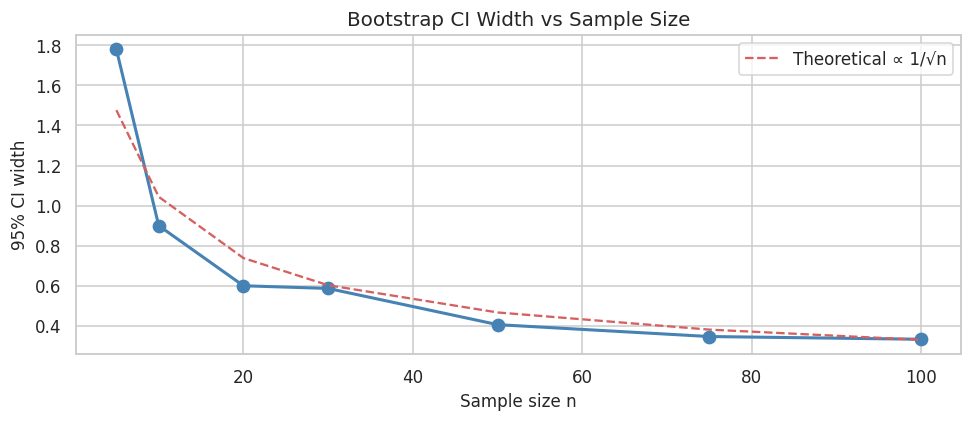

Uncertainty (CI width) shrinks roughly as 1/√n — consistent with the CLT.


In [14]:
# ── 5.4  Bootstrap CI width vs sample size ────────────────────────────
# How does our uncertainty shrink as we get more data?

population = iris["sepal_length"].values   # treat all 150 as population

ns         = [5, 10, 20, 30, 50, 75, 100]
ci_widths  = []

for n in ns:
    subsample = RNG.choice(population, size=n, replace=False)
    lo, hi, _ = bootstrap(subsample, np.mean, B=5_000)
    ci_widths.append(hi - lo)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ns, ci_widths, "o-", color="steelblue", linewidth=2, markersize=8)
theoretical_width = [4 / np.sqrt(n) * population.std() for n in ns]
ax.plot(ns, theoretical_width, "r--", linewidth=1.5, label="Theoretical ∝ 1/√n")
ax.set_xlabel("Sample size n")
ax.set_ylabel("95% CI width")
ax.set_title("Bootstrap CI Width vs Sample Size")
ax.legend()
plt.tight_layout()
plt.show()

print("Uncertainty (CI width) shrinks roughly as 1/√n — consistent with the CLT.")

### Exercise 5
Using the **full iris dataset**, bootstrap a 95% CI for the **correlation** between `petal_length` and `petal_width`.

1. Compute the observed Pearson correlation
2. Run 10,000 bootstrap iterations, re-sampling both variables together (keep pairs)
3. Plot the bootstrap distribution and mark the observed value and CI bounds
4. Is the correlation significantly different from 0? How can you tell from the CI alone?

```python
# Hint — re-sampling pairs:
# indices = RNG.integers(0, n, size=n)   # row indices with replacement
# boot_pl = petal_length[indices]
# boot_pw = petal_width[indices]
# corr    = np.corrcoef(boot_pl, boot_pw)[0, 1]
```

In [ ]:
# Your answer here


---
## Part 6 — Full Simulation Workflow

Bringing it all together: a realistic end-to-end simulation study.

**Scenario:** You are an analyst at an e-commerce company. The historical click-through rate (CTR) is **p = 0.05** (5%). After a design change, you observe **32 clicks in 500 impressions**. Did the CTR actually increase?

We will answer this three ways: simulation, exact binomial test, and bootstrap.

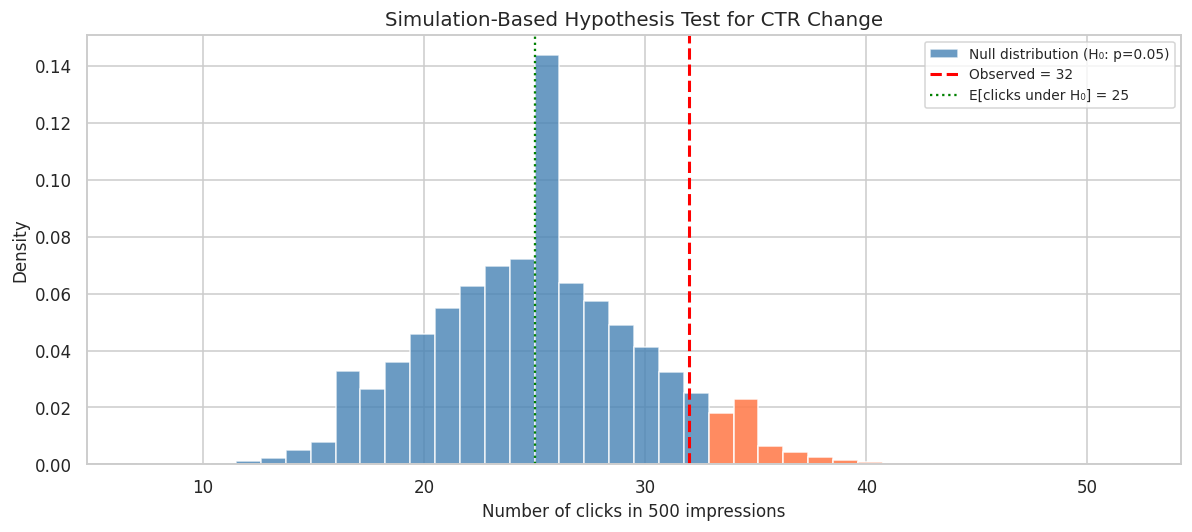

Observed clicks:     32  (6.4% CTR)
Expected under H₀:   25  (5.0% CTR)

p-value (simulation):  0.0940
p-value (exact test):  0.0945

→ Fail to reject H₀: insufficient evidence of a change


In [17]:
# ── 6.1  Simulate the null distribution ──────────────────────────────
# Null hypothesis H₀: CTR = 0.05 (no change)
# Question: how often does H₀ produce 32 or more clicks in 500 trials?

p_null    = 0.05
n_trials  = 500
observed  = 32
n_sims    = 100_000

null_clicks = RNG.binomial(n=n_trials, p=p_null, size=n_sims)
p_value_sim = (null_clicks >= observed).mean()

# Analytical p-value using exact binomial test
p_value_exact = stats.binom.sf(observed - 1, n_trials, p_null)

fig, ax = plt.subplots(figsize=(11, 5))

# Null distribution
counts, bins, patches = ax.hist(null_clicks, bins=40, density=True,
                                color="steelblue", edgecolor="white", alpha=0.8,
                                label="Null distribution (H₀: p=0.05)")

# Colour the rejection region
for patch, left in zip(patches, bins[:-1]):
    if left >= observed:
        patch.set_facecolor("coral")
        patch.set_alpha(0.9)

ax.axvline(observed, color="red", linestyle="--", linewidth=2,
           label=f"Observed = {observed}")
ax.axvline(n_trials * p_null, color="green", linestyle=":", linewidth=1.5,
           label=f"E[clicks under H₀] = {n_trials*p_null:.0f}")

ax.set_xlabel("Number of clicks in 500 impressions")
ax.set_ylabel("Density")
ax.set_title("Simulation-Based Hypothesis Test for CTR Change")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Observed clicks:     {observed}  ({observed/n_trials:.1%} CTR)")
print(f"Expected under H₀:   {n_trials * p_null:.0f}  ({p_null:.1%} CTR)")
print(f"\np-value (simulation):  {p_value_sim:.4f}")
print(f"p-value (exact test):  {p_value_exact:.4f}")
print(f"\n→ {'Reject H₀: CTR has significantly increased (α=0.05)' if p_value_sim < 0.05 else 'Fail to reject H₀: insufficient evidence of a change'}")

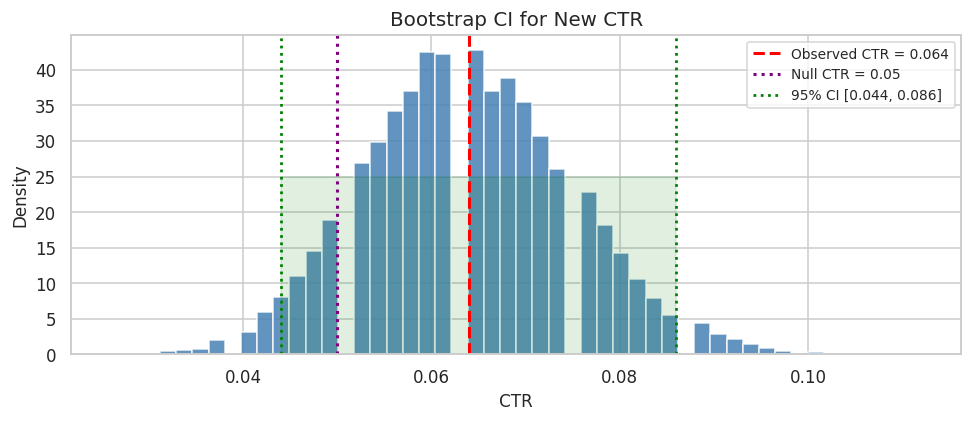

Bootstrap 95% CI: [0.0440,  0.0860]
Null CTR (0.05) is inside the CI.

Conclusion: The new CTR = 6.4%. The 95% CI [0.044, 0.086] includes the null value of 0.05, so H₀ cannot be rejected.


In [18]:
# ── 6.2  Bootstrap CI for the new CTR ────────────────────────────────
# Construct a 95% CI for the true CTR from the observed data.

observed_data = np.array([1] * observed + [0] * (n_trials - observed))
lo, hi, boot_ctrs = bootstrap(observed_data, np.mean, B=10_000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_ctrs, bins=50, density=True, color="steelblue",
        edgecolor="white", alpha=0.85)
ax.axvline(observed / n_trials, color="red",   linestyle="--", linewidth=2,
           label=f"Observed CTR = {observed/n_trials:.3f}")
ax.axvline(p_null,              color="purple", linestyle=":",  linewidth=2,
           label=f"Null CTR = {p_null}")
ax.axvline(lo, color="green", linestyle=":", linewidth=1.8, label=f"95% CI [{lo:.3f}, {hi:.3f}]")
ax.axvline(hi, color="green", linestyle=":", linewidth=1.8)
ax.fill_betweenx([0, 25], lo, hi, alpha=0.12, color="green")
ax.set_xlabel("CTR")
ax.set_ylabel("Density")
ax.set_title("Bootstrap CI for New CTR")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Bootstrap 95% CI: [{lo:.4f},  {hi:.4f}]")
print(f"Null CTR (0.05) is {'OUTSIDE' if p_null < lo else 'inside'} the CI.")
print(f"\nConclusion: The new CTR = {observed/n_trials:.1%}. "
      f"The 95% CI [{lo:.3f}, {hi:.3f}] {'excludes' if p_null < lo else 'includes'} "
      f"the null value of {p_null}, {'supporting rejection of H₀.' if p_null < lo else 'so H₀ cannot be rejected.'}")

---
## Part 7 — Common Distributions via Simulation

Seeing distributions visually cements understanding far better than formulas alone.

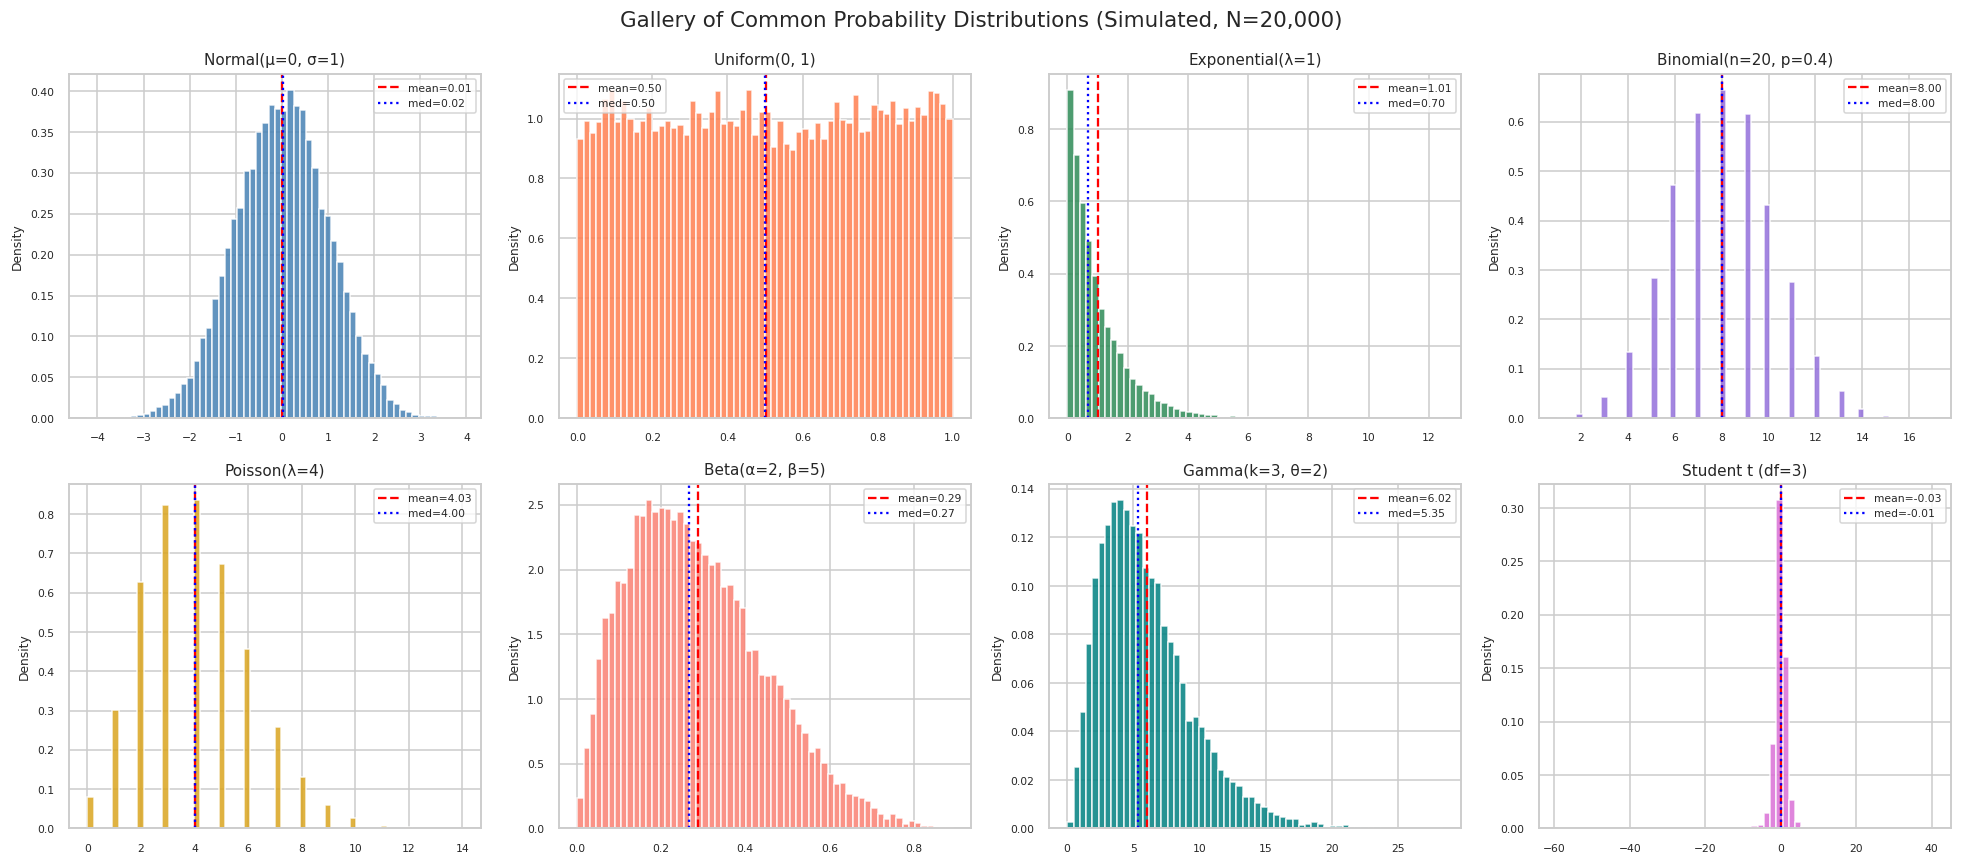

In [19]:
# ── 7.1  Gallery of common distributions ─────────────────────────────

N = 20_000
distributions = [
    ("Normal(μ=0, σ=1)",       RNG.normal(0, 1, N),            "steelblue"),
    ("Uniform(0, 1)",           RNG.uniform(0, 1, N),           "coral"),
    ("Exponential(λ=1)",        RNG.exponential(1, N),          "seagreen"),
    ("Binomial(n=20, p=0.4)",   RNG.binomial(20, 0.4, N),       "mediumpurple"),
    ("Poisson(λ=4)",            RNG.poisson(4, N),              "goldenrod"),
    ("Beta(α=2, β=5)",          RNG.beta(2, 5, N),              "salmon"),
    ("Gamma(k=3, θ=2)",         RNG.gamma(3, 2, N),             "teal"),
    ("Student t (df=3)",        RNG.standard_t(3, N),           "orchid"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Gallery of Common Probability Distributions (Simulated, N=20,000)", fontsize=14)

for ax, (name, data, color) in zip(axes.flat, distributions):
    ax.hist(data, bins=60, density=True, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="red",   linestyle="--", linewidth=1.5, label=f"mean={data.mean():.2f}")
    ax.axvline(np.median(data), color="blue", linestyle=":", linewidth=1.5, label=f"med={np.median(data):.2f}")
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel("Density", fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

In [20]:
# ── 7.2  Simulation summary table ─────────────────────────────────────

summary_rows = []
for name, data, _ in distributions:
    summary_rows.append({
        "Distribution": name,
        "Simulated Mean":  round(data.mean(), 4),
        "Simulated Std":   round(data.std(), 4),
        "Skewness":        round(stats.skew(data), 3),
        "Kurtosis":        round(stats.kurtosis(data), 3),
    })

display(pd.DataFrame(summary_rows))

,Distribution,Simulated Mean,Simulated Std,Skewness,Kurtosis
0,"Normal(μ=0, σ=1)",0.0107,1.0072,-0.034,-0.070
1,"Uniform(0, 1)",0.5023,0.2902,-0.001,-1.217
2,Exponential(λ=1),1.0073,1.0166,2.079,6.937
3,"Binomial(n=20, p=0.4)",8.0000,2.1813,0.101,-0.119
4,Poisson(λ=4),4.0331,2.0127,0.490,0.198
5,"Beta(α=2, β=5)",0.2873,0.1593,0.595,-0.095
6,"Gamma(k=3, θ=2)",6.0228,3.4811,1.135,1.803
7,Student t (df=3),-0.0267,1.7584,-1.903,93.354


### Exercise 6 — Final Challenge

**The Inspection Paradox (a.k.a. the waiting-time paradox)**

Buses arrive at a stop at a rate of **1 per 10 minutes** on average (Poisson process, so gaps ~ Exponential(λ=1/10)).

**Naive intuition:** If I arrive at a random time, I should wait on average 5 minutes (half the average gap).

**The paradox:** You actually wait **10 minutes** on average. A random arrival is more likely to land in a *long* gap than a short one — so you systematically experience longer-than-average gaps.

**Your task:**
1. Simulate 100,000 buses arriving over time using `np.cumsum(RNG.exponential(10, size=100_000))`
2. Pick 10,000 random arrival times for passengers uniformly within the total time window
3. For each passenger, find the time until the next bus
4. Plot the distribution of waiting times and mark the mean
5. Compare to the naive expectation of 5 minutes and the true expectation of 10 minutes

```python
# Hint — finding next bus for a passenger:
# np.searchsorted(bus_times, passenger_time)   →  index of next bus
```

In [ ]:
# Your answer here


---
## Summary

| Concept | Key Takeaway |
|---|---|
| **Law of Large Numbers** | Empirical frequency → true probability as n → ∞; error ≈ O(1/√n) |
| **Central Limit Theorem** | Sample means are normal regardless of parent distribution; kicks in ~n=30 |
| **Monty Hall** | Switching wins 2/3 of the time — simulation makes this undeniable |
| **Birthday Problem** | Only 23 people needed for 50% chance of shared birthday |
| **Gambler's Ruin** | Even a small house edge drastically reduces win probability |
| **Monte Carlo Integration** | Estimate any integral by averaging function values at random points |
| **Bootstrap** | Re-sample with replacement to get a CI for *any* statistic |
| **Simulation-based testing** | Simulate the null distribution to compute p-values empirically |
| **Distribution gallery** | Mean ≠ median when skewed; simulate to build intuition |

---
### Take-Home Assignment

Choose a real dataset from Kaggle or UCI. Pick **one numerical column** of interest.

1. **Bootstrap** a 95% CI for the mean and median (B = 10,000). Do they overlap?
2. **Simulate the CLT**: draw 5,000 samples of size n=30. Plot the sampling distribution of the mean and overlay a Normal curve. Does the CLT hold?
3. **Design a simulation test**: state a null hypothesis about your column (e.g. "mean = X"). Simulate the null distribution and compute a p-value for your observed mean.
4. Write a short paragraph (5–6 sentences) interpreting all three results together.

**Bring your notebook to the next session.**

---
*Eötvös Loránd University (ELTE) · Faculty of Informatics · Introduction to Data Science*